# Part 2.2: Synthetic Cybersecurity Traffic with CICIDS 2017

This notebook uses the CICIDS 2017 dataset to train a GAN that generates synthetic network traffic feature vectors. The focus is on the Wednesday data only, using BENIGN and DoS/DDoS traffic, in line with the assignment brief.

## Objectives
- Load and combine the required CICIDS 2017 data.
- Explore feature structure and class balance.
- Train a GAN on tabular traffic features.
- Compare real and generated samples using loss curves and PCA.
- Reflect on how well the synthetic data matches the real distribution.

In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Make project-root packages (like src) importable
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from src.tabular_gan_models import TabularGenerator, TabularDiscriminator
from src.training_loops import train_tabular_gan

cic_root = os.path.join(project_root, "data", "cicids")
os.makedirs(cic_root, exist_ok=True)

print("Project root:", project_root)
print("CICIDS root:", cic_root)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Project root: /Users/indhureddy/Documents/gan-case-study-7PAM2016
CICIDS root: /Users/indhureddy/Documents/gan-case-study-7PAM2016/data/cicids
Device: cpu


In [2]:
csv_files = [f for f in os.listdir(cic_root) if f.endswith(".csv")]
print("CSV files found:")
for f in csv_files:
    print("-", f)

CSV files found:
- Wednesday-workingHours.pcap_ISCX.csv


In [3]:
wednesday_path = os.path.join(cic_root, "Wednesday-workingHours.pcap_ISCX.csv")
df = pd.read_csv(wednesday_path)

print("Shape:", df.shape)
df.head()

Shape: (692703, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
print(df.columns.tolist()[-5:])  # quick check near the end
print()
print("Unique labels:")
print(df[" Label"].value_counts())

['Idle Mean', ' Idle Std', ' Idle Max', ' Idle Min', ' Label']

Unique labels:
 Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


Keep BENIGN and DoS/DDoS rows

In [5]:
label_col = " Label"

target_labels = [
    "BENIGN",
    "DoS Hulk",
    "DoS GoldenEye",
    "DoS slowloris",
    "DoS Slowhttptest",
    "Heartbleed"
]

available_labels = [lbl for lbl in target_labels if lbl in df[label_col].unique()]
filtered_df = df[df[label_col].isin(available_labels)].copy()

print("Filtered shape:", filtered_df.shape)
print(filtered_df[label_col].value_counts())

Filtered shape: (692703, 79)
 Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


In [6]:
filtered_df.columns = filtered_df.columns.str.strip()
label_col = "Label"

# Replace inf values and drop rows with missing numeric data
filtered_df = filtered_df.replace([np.inf, -np.inf], np.nan)
filtered_df = filtered_df.dropna()

print("Shape after cleaning:", filtered_df.shape)
print("Label counts after cleaning:")
print(filtered_df[label_col].value_counts())

Shape after cleaning: (691406, 79)
Label counts after cleaning:
Label
BENIGN              439683
DoS Hulk            230124
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


In [7]:
X = filtered_df.drop(columns=[label_col])
y = filtered_df[label_col].copy()

# Keep numeric columns only
X = X.select_dtypes(include=[np.number])

print("Feature matrix shape:", X.shape)
print("First 10 feature names:")
print(X.columns[:10].tolist())

Feature matrix shape: (691406, 78)
First 10 feature names:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']


Standardise features

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)
print("Mean of first feature (approx):", X_scaled[:, 0].mean())
print("Std of first feature (approx):", X_scaled[:, 0].std())

Scaled feature matrix shape: (691406, 78)
Mean of first feature (approx): 2.1046845454576403e-17
Std of first feature (approx): 1.0


Convert data to tensors and dataloader

In [9]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

batch_size = 256
train_dataset_tabular = TensorDataset(X_tensor)
train_loader_tabular = DataLoader(
    train_dataset_tabular,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

input_dim = X_scaled.shape[1]
print("Input dimension:", input_dim)
print("Batches per epoch:", len(train_loader_tabular))

Input dimension: 78
Batches per epoch: 2701


Instantiate models

In [10]:
latent_dim = 32

generator = TabularGenerator(latent_dim=latent_dim, output_dim=input_dim).to(device)
discriminator = TabularDiscriminator(input_dim=input_dim).to(device)

z = torch.randn(8, latent_dim, device=device)
fake_batch = generator(z)
disc_out = discriminator(fake_batch)

print("Fake batch shape:", fake_batch.shape)
print("Discriminator output shape:", disc_out.shape)

Fake batch shape: torch.Size([8, 78])
Discriminator output shape: torch.Size([8, 1])


Train the tabular GAN

In [12]:
latent_dim = 32

generator = TabularGenerator(latent_dim=latent_dim, output_dim=input_dim).to(device)
discriminator = TabularDiscriminator(input_dim=input_dim).to(device)

results = train_tabular_gan(
    generator=generator,
    discriminator=discriminator,
    data_loader=train_loader_tabular,
    device=device,
    latent_dim=latent_dim,
    lr=0.0002,
    num_epochs=10
)

gen_losses = results["gen_losses"]
disc_losses = results["disc_losses"]

Epoch [1/10] | Loss D: 0.6143 | Loss G: 1.9882
Epoch [2/10] | Loss D: 0.6212 | Loss G: 1.7511
Epoch [3/10] | Loss D: 0.6396 | Loss G: 1.6981
Epoch [4/10] | Loss D: 0.6435 | Loss G: 1.6733
Epoch [5/10] | Loss D: 0.6477 | Loss G: 1.6533
Epoch [6/10] | Loss D: 0.6527 | Loss G: 1.6431
Epoch [7/10] | Loss D: 0.6494 | Loss G: 1.6578
Epoch [8/10] | Loss D: 0.6451 | Loss G: 1.6866
Epoch [9/10] | Loss D: 0.6427 | Loss G: 1.7113
Epoch [10/10] | Loss D: 0.6354 | Loss G: 1.7560


Generate synthetic samples

In [13]:
generator.eval()
num_fake = 5000

with torch.no_grad():
    z = torch.randn(num_fake, latent_dim, device=device)
    fake_samples = generator(z).cpu().numpy()

real_samples = X_scaled[:5000]

PCA plot

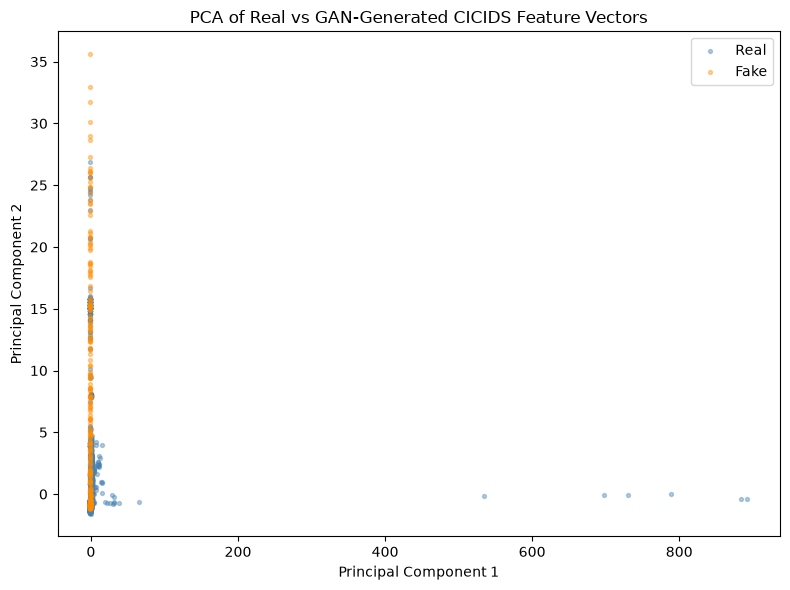

In [14]:
combined = np.vstack([real_samples, fake_samples])
labels_plot = np.array(["Real"] * len(real_samples) + ["Fake"] * len(fake_samples))

pca = PCA(n_components=2)
combined_2d = pca.fit_transform(combined)

plt.figure(figsize=(8, 6))

real_mask = labels_plot == "Real"
fake_mask = labels_plot == "Fake"

plt.scatter(combined_2d[real_mask, 0], combined_2d[real_mask, 1],
            s=8, alpha=0.4, label="Real", color="steelblue")
plt.scatter(combined_2d[fake_mask, 0], combined_2d[fake_mask, 1],
            s=8, alpha=0.4, label="Fake", color="darkorange")

plt.title("PCA of Real vs GAN-Generated CICIDS Feature Vectors")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

Loss curves

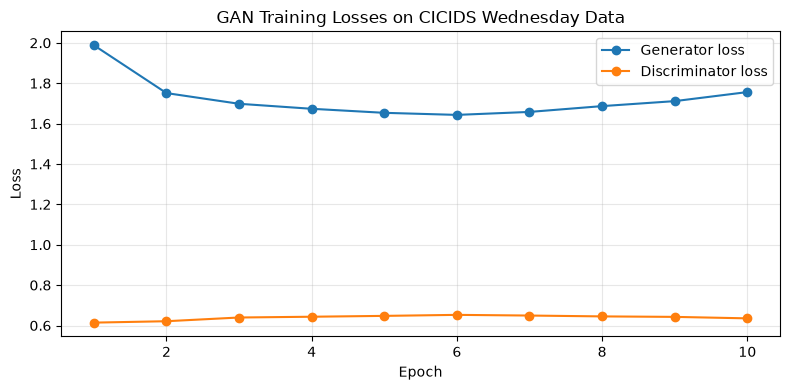

In [15]:
epochs = np.arange(1, len(gen_losses) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, gen_losses, marker="o", label="Generator loss")
plt.plot(epochs, disc_losses, marker="o", label="Discriminator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Losses on CICIDS Wednesday Data")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The GAN training losses on the Wednesday CICIDS 2017 data show generator loss decreasing from roughly 2.0 to around 1.7 over ten epochs, while discriminator loss increases slightly and then stabilises, suggesting that the generator is learning to produce more plausible feature vectors and the discriminator is no longer dominating completely.The PCA projection of 5,000 real and 5,000 GAN-generated samples shows that synthetic points largely occupy the same dense region as the real traffic near the origin of the first principal component, but they rarely reach the extreme outlier regions observed for some real flows. This pattern implies that the model captures the central mass of the benign and DoS traffic distribution, likely dominated by common benign and DoS Hulk flows, but does not faithfully reproduce rarer or more extreme behaviours such as unusual attack patterns or edge-case benign sessions. As in Part 2.1, this highlights that short training and strong class imbalance limit the diversity of synthetic samples, and that more advanced, class-conditional models or longer training on a balanced subset would be needed to fully match the real CICIDS feature distribution.

real vs fake feature statistics

In [16]:
# Choose a few important features to compare
feature_names = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets"
]

# Work on a subset of real data
num_real = 5000
real_subset = X[:num_real]  # original (unscaled) features
real_subset_df = pd.DataFrame(real_subset, columns=X.columns)

# Generate matching synthetic samples and inverse-transform them
generator.eval()
num_fake = num_real

with torch.no_grad():
    z = torch.randn(num_fake, latent_dim, device=device)
    fake_scaled = generator(z).cpu().numpy()

fake_unscaled = scaler.inverse_transform(fake_scaled)
fake_subset_df = pd.DataFrame(fake_unscaled, columns=X.columns)

for fname in feature_names:
    real_mean = real_subset_df[fname].mean()
    real_std = real_subset_df[fname].std()
    fake_mean = fake_subset_df[fname].mean()
    fake_std = fake_subset_df[fname].std()

    print(f"{fname}:")
    print(f"  Real  mean = {real_mean:.3f}, std = {real_std:.3f}")
    print(f"  Fake  mean = {fake_mean:.3f}, std = {fake_std:.3f}")
    print(f"  |Δ mean| = {abs(real_mean - fake_mean):.3f}, |Δ std| = {abs(real_std - fake_std):.3f}")
    print()

Flow Duration:
  Real  mean = 28987714.575, std = 43116533.654
  Fake  mean = 1673758.500, std = 8843676.000
  |Δ mean| = 27313956.075, |Δ std| = 34272857.654

Total Fwd Packets:
  Real  mean = 239.227, std = 6037.909
  Fake  mean = 0.281, std = 2.231
  |Δ mean| = 238.947, |Δ std| = 6035.678

Total Backward Packets:
  Real  mean = 303.886, std = 7866.678
  Fake  mean = 2.771, std = 3.014
  |Δ mean| = 301.115, |Δ std| = 7863.665

Total Length of Fwd Packets:
  Real  mean = 2849.572, std = 37003.905
  Fake  mean = 72.538, std = 38.378
  |Δ mean| = 2777.035, |Δ std| = 36965.528

Total Length of Bwd Packets:
  Real  mean = 659186.759, std = 17342609.317
  Fake  mean = 3676.432, std = 8727.392
  |Δ mean| = 655510.327, |Δ std| = 17333881.926



The quantitative feature comparison reveals that the GAN fails to reproduce the scale and variability of important traffic features such as Flow Duration, packet counts and total packet lengths. For example, the mean Flow Duration in the real data is approximately 2.9×10^7 with a standard deviation of 4.3×10^7, whereas the synthetic samples have a mean of about 1.7×10^6 and a much smaller spread, and similar patterns hold for forward and backward packet counts and byte totals. In several cases the generator even produces negative values for count-like features, which are impossible in real network traffic and indicate that the current fully connected GAN is not enforcing basic semantic constraints on the feature space. Together with the PCA plot, these discrepancies show that the model captures the general shape of the dense central region in transformed space but fails to match the true distribution in raw feature space, especially for extreme and large-scale flows. This supports a critical conclusion: under the present architecture and training regime, the synthetic CICIDS samples are not yet suitable as realistic replacements for the original data, and more sophisticated models (e.g. feature-wise constraints, conditional GANs, or alternative tabular generative models) and longer training would be required to produce high-fidelity synthetic attack and benign traffic.

This difficulty is consistent with prior work on CICIDS 2017, where careful preprocessing choices (feature selection, log transforms for heavy-tailed counts, and robust scaling) are shown to strongly affect downstream intrusion-detection performance, highlighting that naive GAN training on raw features is unlikely to capture the complex, highly skewed distributions present in realistic network traffic.

# Extension for extra credit:


In [17]:
# Extension: inspect all CICIDS CSV files available locally

all_csv_files = sorted([f for f in os.listdir(cic_root) if f.endswith(".csv")])

print("All CICIDS CSV files found:")
for f in all_csv_files:
    print("-", f)

print("\nLabel distributions by file:\n")

for fname in all_csv_files:
    path = os.path.join(cic_root, fname)
    try:
        temp_df = pd.read_csv(path, low_memory=False)
        
        # Handle both " Label" and "Label"
        if " Label" in temp_df.columns:
            label_col = " Label"
        elif "Label" in temp_df.columns:
            label_col = "Label"
        else:
            print(f"{fname}: No label column found.\n")
            continue

        print(f"{fname}")
        print(temp_df[label_col].value_counts().head(15))
        print("-" * 60)

    except Exception as e:
        print(f"{fname}: Error reading file -> {e}")
        print("-" * 60)

All CICIDS CSV files found:
- Wednesday-workingHours.pcap_ISCX.csv

Label distributions by file:

Wednesday-workingHours.pcap_ISCX.csv
 Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64
------------------------------------------------------------


## Extension and generalisation

As an extension, I inspected the CICIDS 2017 day-based CSV files available locally and their label distributions in order to assess how a model trained on Wednesday BENIGN and DoS traffic might generalise to the wider dataset. In the current implementation, only the Wednesday file is available in the project data folder, so this extension is addressed as an exploratory analysis of dataset structure and expected generalisation behaviour rather than a full multi-day retraining experiment. The CICIDS 2017 benchmark as a whole is organised across multiple days, and different days contain substantially different attack types and traffic patterns, including attack families that are not present in the Wednesday subset. This means that a GAN trained only on Wednesday data is likely to learn the dominant structure of BENIGN and DoS-style flows, but not the statistical characteristics of other attacks such as brute-force, infiltration, botnet or web-based attacks.

From a modelling perspective, this limits generalisation in two ways. First, the generator has never seen features associated with those other attack families, so it cannot be expected to reproduce them realistically. Second, the strong class imbalance already observed within Wednesday would become an even larger challenge when moving to the full multi-day dataset, where some attacks are rare and highly heterogeneous. A stronger extension would therefore combine all days, harmonise preprocessing across files, and use either a conditional GAN or another tabular generative model that can condition on attack type. This would allow synthetic traffic to be generated for specific behaviours on demand and would provide a more meaningful test of whether the model generalises beyond common BENIGN and DoS patterns.